In [1]:
import pandas as pd

In [2]:
# Load full dataset.
# df = pd.read_parquet("../assets/Taxi_Trips_compact.parquet")

In [ ]:
import pandas as pd
import h3
import matplotlib.pyplot as plt

# Load the trip data.
df = pd.read_csv("../assets/Taxi_Trips_sample.parquet")

In [4]:
df

,trip_id_int,taxi_id_int,trip_start,trip_end,trip_seconds,trip_miles,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,has_electronic_fee
0,1,1.0,2026-05-01 00:00:00,2026-05-01 00:15:00,1269,13.04,56.0,39.0,33.00,7.70,0.0,5.0,46.20,credit card,taxicab insurance agency llc,41.792592,-87.769615,41.808916,-87.596183,True
1,2,2.0,2026-05-01 00:00:00,2026-05-01 00:00:00,422,1.57,32.0,28.0,7.36,0.00,0.0,0.0,7.86,mobile,flash cab,41.878866,-87.625192,41.874005,-87.663518,True
2,3,3.0,2026-05-01 00:00:00,2026-05-01 00:15:00,1083,9.93,76.0,NaN,26.25,0.00,0.0,5.0,31.25,cash,5 star taxi,41.980264,-87.913625,NaN,NaN,False
3,4,4.0,2026-05-01 00:00:00,2026-05-01 00:30:00,1980,13.90,56.0,8.0,37.50,0.00,0.0,4.0,41.50,cash,transit administrative center inc,41.792592,-87.769615,41.899602,-87.633308,False
4,5,5.0,2026-05-01 00:00:00,2026-05-01 00:30:00,1967,16.39,7.0,71.0,42.75,8.65,0.0,0.0,51.40,prcard,city service,41.922686,-87.649489,41.744205,-87.656306,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,1023.0,2026-04-25 13:45:00,2026-04-25 14:00:00,1050,2.58,8.0,24.0,12.04,0.00,0.0,0.0,12.54,mobile,taxicab insurance agency llc,41.899602,-87.633308,41.901207,-87.676356,True
99996,99997,1038.0,2026-04-25 13:45:00,2026-04-25 14:15:00,1347,4.52,8.0,7.0,18.00,3.70,0.0,0.0,22.20,credit card,blue ribbon taxi association,41.891972,-87.612945,41.921877,-87.664078,True
99997,99998,1314.0,2026-04-25 13:45:00,2026-04-25 14:00:00,1039,7.90,8.0,41.0,22.50,0.00,0.0,2.0,24.50,cash,sun taxi,41.899602,-87.633308,41.794090,-87.592311,False
99998,99999,391.0,2026-04-25 13:45:00,2026-04-25 14:00:00,712,1.11,8.0,8.0,8.00,0.00,0.0,0.0,8.00,cash,chicago independents,41.899156,-87.626211,41.891972,-87.612945,False


In [13]:
H3_HEXAGON_RESOLUTION = 8


def to_h3_cell(lat, lon):
    if pd.isna(lat) or pd.isna(lon):
        return None

    lat = float(lat)
    lon = float(lon)

    if not (-90 <= lat <= 90 and -180 <= lon <= 180):
        return None

    return h3.latlng_to_cell(lat, lon, H3_HEXAGON_RESOLUTION)


# Discretize pickup and dropoff coordinates to H3 cells.
df["start_h3"] = [to_h3_cell(lat, lon) for lat, lon in zip(df["pickup_lat"], df["pickup_lon"])]
df["end_h3"] = [to_h3_cell(lat, lon) for lat, lon in zip(df["dropoff_lat"], df["dropoff_lon"])]

start_counts = df["start_h3"].dropna().value_counts().sort_values(ascending=True)
end_counts = df["end_h3"].dropna().value_counts().sort_values(ascending=True)

In [14]:
import folium
import branca

# # Build an interactive folium map with H3 hex layers and tract choropleths
# bounds = tracts_counts.total_bounds  # minx, miny, maxx, maxy
# center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]

m = folium.Map(location=center, zoom_start=11, tiles="CartoDB positron")

# Colormaps
start_cmap = branca.colormap.LinearColormap(["yellow", "orange", "red"], vmin=start_hex_gdf["count"].min(), vmax=start_hex_gdf["count"].max())
end_cmap = branca.colormap.LinearColormap(["yellow", "orange", "red"], vmin=end_hex_gdf["count"].min(), vmax=end_hex_gdf["count"].max())

# Start H3 layer
start_layer = folium.FeatureGroup(name="Start H3 hexagons", show=False)
folium.GeoJson(
    start_hex_gdf.to_json(),
    style_function=lambda feature, cmap=start_cmap: {
        "fillColor": cmap(feature["properties"].get("count", 0)),
        "color": "white",
        "weight": 0.2,
        "fillOpacity": 0.7,
    },
    tooltip=folium.GeoJsonTooltip(fields=["h3_cell", "count"], aliases=["h3", "count"]),
).add_to(start_layer)
start_layer.add_to(m)

# End H3 layer
end_layer = folium.FeatureGroup(name="End H3 hexagons", show=False)
folium.GeoJson(
    end_hex_gdf.to_json(),
    style_function=lambda feature, cmap=end_cmap: {
        "fillColor": cmap(feature["properties"].get("count", 0)),
        "color": "white",
        "weight": 0.2,
        "fillOpacity": 0.7,
    },
    tooltip=folium.GeoJsonTooltip(fields=["h3_cell", "count"], aliases=["h3", "count"]),
).add_to(end_layer)
end_layer.add_to(m)

# Tract choropleth layers
tracts_geojson = tracts_counts.reset_index().to_json()

tracts_start = folium.FeatureGroup(name="Tract starts", show=True)
folium.GeoJson(
    tracts_geojson,
    style_function=lambda feature: {
        "fillColor": branca.colormap.LinearColormap(["white", "blue"], vmin=0, vmax=tracts_counts["start_count"].max())(feature["properties"].get("start_count", 0)),
        "color": "#444444",
        "weight": 0.2,
        "fillOpacity": 0.6,
    },
    tooltip=folium.GeoJsonTooltip(fields=["geoid10", "start_count"], aliases=["geoid10", "start_count"]),
).add_to(tracts_start)
tracts_start.add_to(m)

tracts_end = folium.FeatureGroup(name="Tract ends", show=False)
folium.GeoJson(
    tracts_geojson,
    style_function=lambda feature: {
        "fillColor": branca.colormap.LinearColormap(["white", "green"], vmin=0, vmax=tracts_counts["end_count"].max())(feature["properties"].get("end_count", 0)),
        "color": "#444444",
        "weight": 0.2,
        "fillOpacity": 0.6,
    },
    tooltip=folium.GeoJsonTooltip(fields=["geoid10", "end_count"], aliases=["geoid10", "end_count"]),
).add_to(tracts_end)
tracts_end.add_to(m)

# Add colormap legends
start_cmap.caption = 'Start hex counts'
start_cmap.add_to(m)
end_cmap.caption = 'End hex counts'
end_cmap.add_to(m)

folium.LayerControl().add_to(m)

# Display map
m

NameError: name 'start_hex_gdf' is not defined

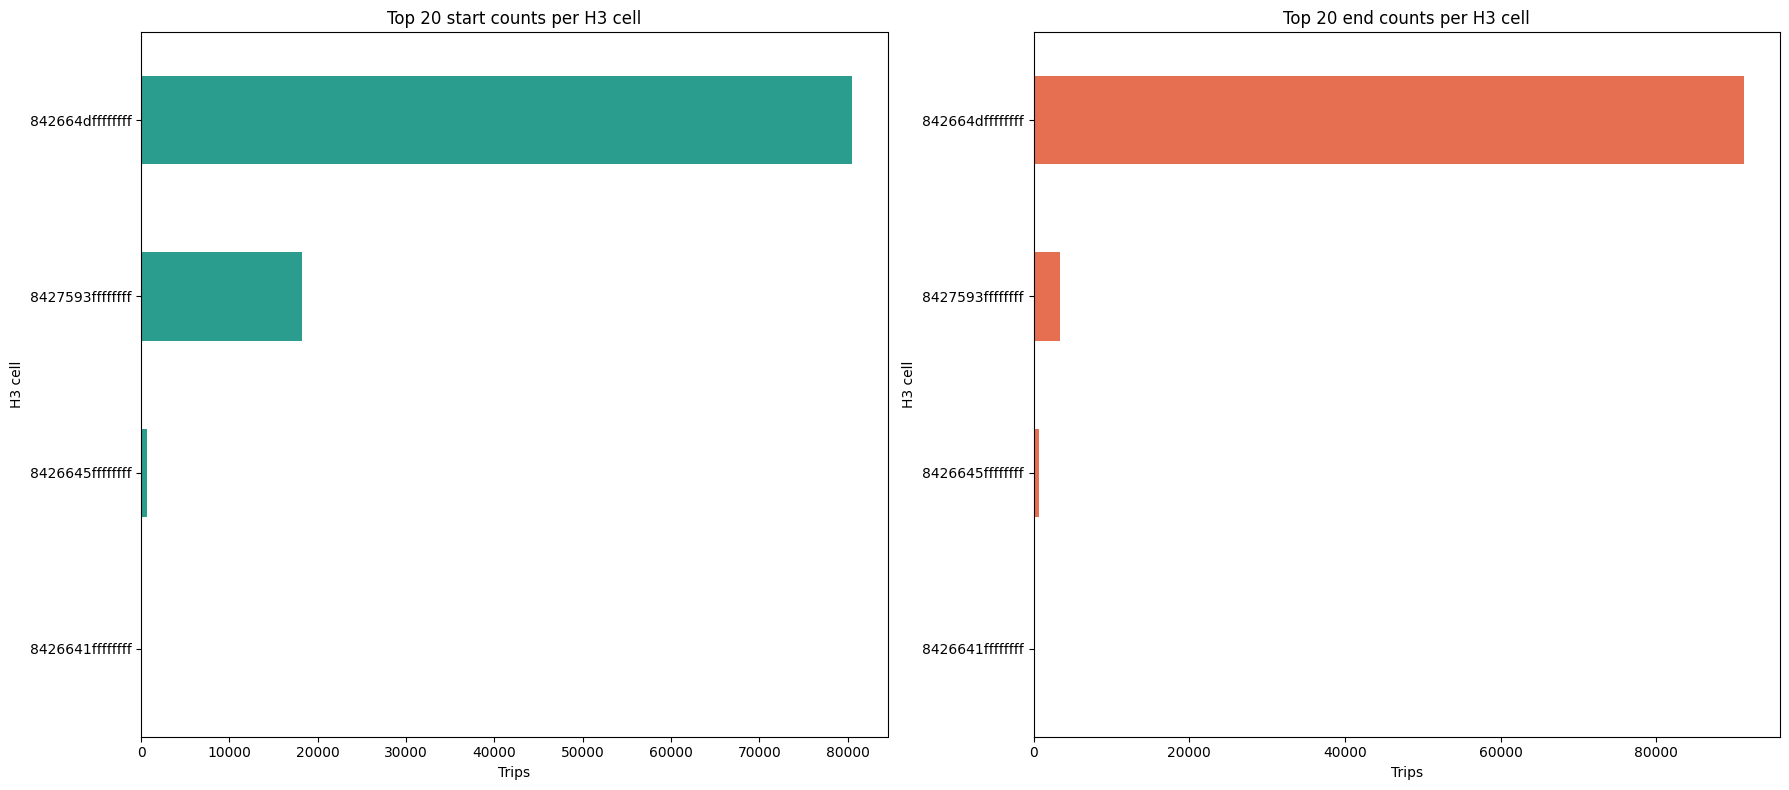

In [7]:
top_n = 20
start_counts_top = start_counts.sort_values(ascending=False).head(top_n).sort_values(ascending=True)
end_counts_top = end_counts.sort_values(ascending=False).head(top_n).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=False)

start_counts_top.plot(kind="barh", ax=axes[0], color="#2a9d8f")
axes[0].set_title("Top 20 start counts per H3 cell")
axes[0].set_xlabel("Trips")
axes[0].set_ylabel("H3 cell")

end_counts_top.plot(kind="barh", ax=axes[1], color="#e76f51")
axes[1].set_title("Top 20 end counts per H3 cell")
axes[1].set_xlabel("Trips")
axes[1].set_ylabel("H3 cell")

plt.tight_layout()

NameError: name 'start_hex_gdf' is not defined

NameError: name 'start_hex_gdf' is not defined

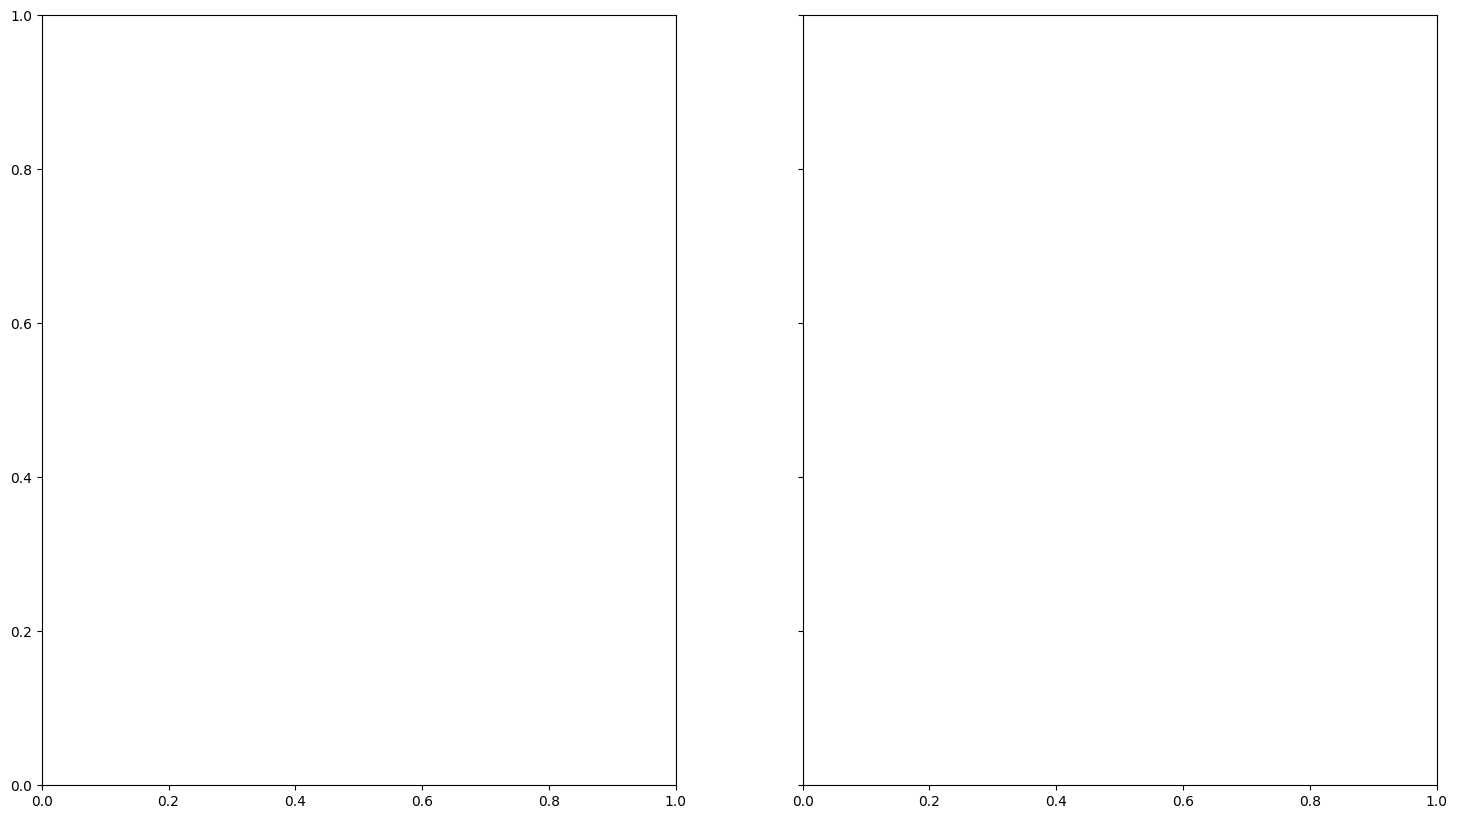

In [8]:
# Overlay the Chicago community boundaries and the H3 heatmaps in one figure.
fig, axes = plt.subplots(1, 2, figsize=(18, 10), sharex=True, sharey=True)

for ax, hex_gdf, title in [
    (axes[0], start_hex_gdf, "Start H3 heatmap over Chicago"),
    (axes[1], end_hex_gdf, "End H3 heatmap over Chicago"),
]:
    tracts.plot(ax=ax, color="#f4efe8", edgecolor="#6b6b6b", linewidth=0.5)
    hex_gdf.plot(
        column="count",
        ax=ax,
        cmap="YlOrRd",
        linewidth=0.15,
        edgecolor="white",
        alpha=0.72,
        legend=True,
        legend_kwds={"label": "Trips per H3 cell", "shrink": 0.75},
    )
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal")
    ax.set_facecolor("white")

plt.tight_layout()

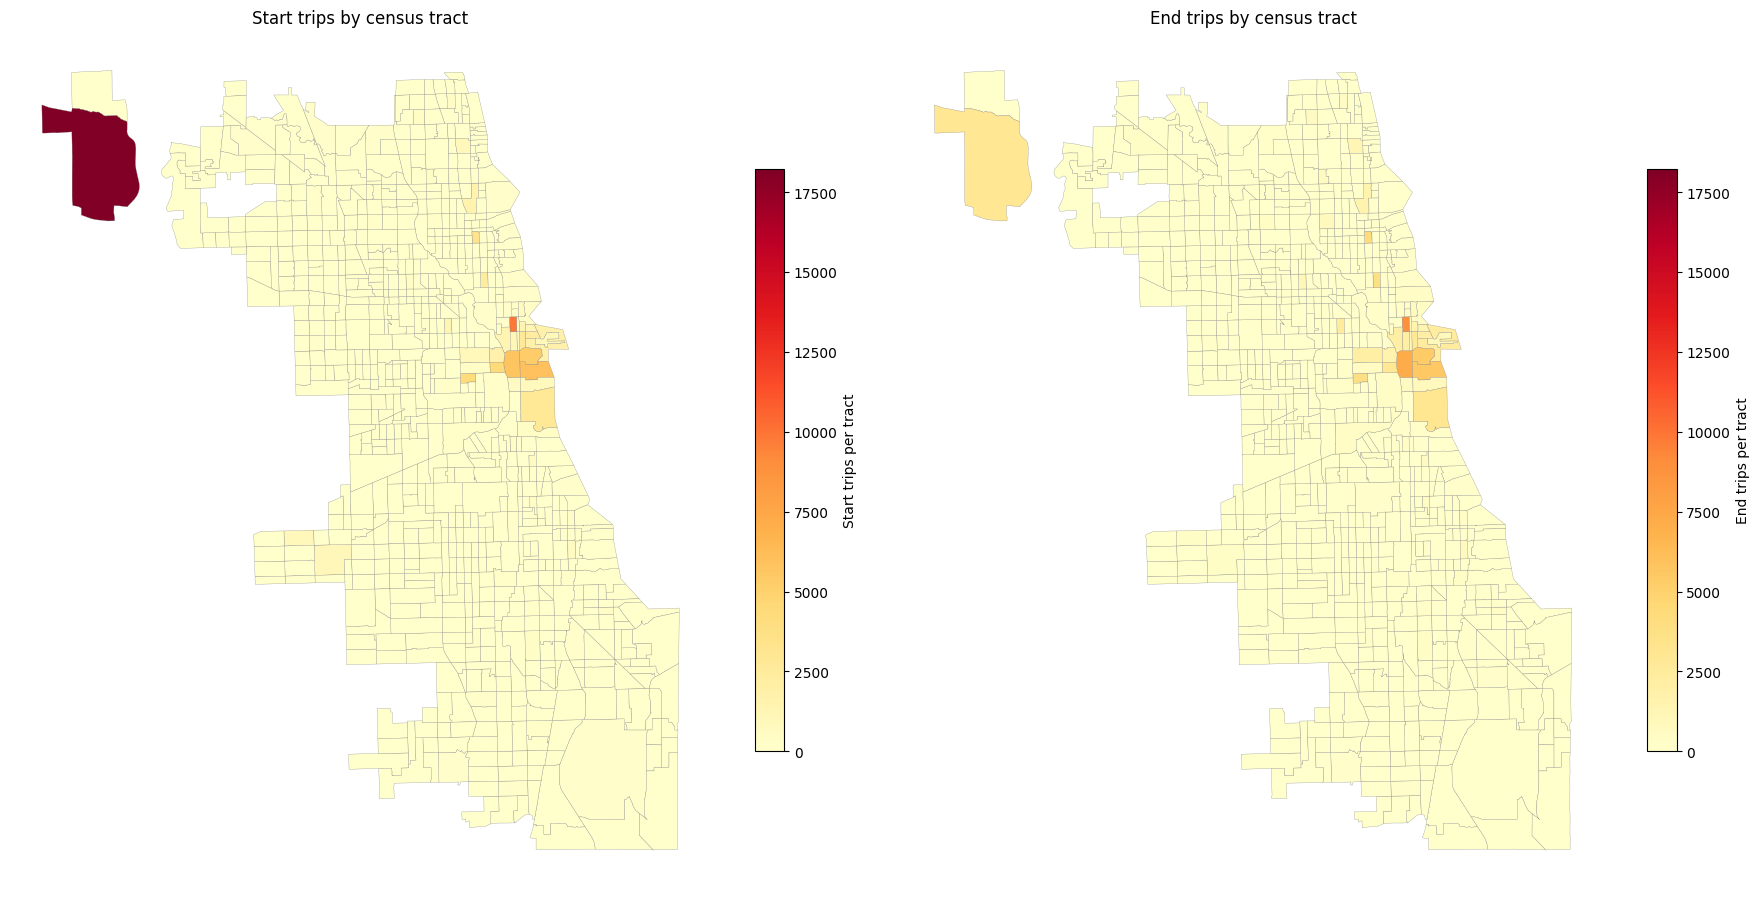

In [ ]:
# Aggregate trips by census tract and plot separate tract-level heatmaps for starts and ends
tracts = gpd.read_file("../assets/Boundaries - Census Tracts - 2010.geojson").to_crs("EPSG:4326")

# Create point GeoDataFrames for starts and ends
starts = gpd.GeoDataFrame(df[["pickup_lon", "pickup_lat"]].copy(),
                          geometry=gpd.points_from_xy(df["pickup_lon"], df["pickup_lat"]),
                          crs="EPSG:4326")
ends = gpd.GeoDataFrame(df[["dropoff_lon", "dropoff_lat"]].copy(),
                        geometry=gpd.points_from_xy(df["dropoff_lon"], df["dropoff_lat"]),
                        crs="EPSG:4326")

# Spatial join points -> tracts
starts_join = gpd.sjoin(starts, tracts[["geoid10", "geometry"]], how="left", predicate="within")
ends_join = gpd.sjoin(ends, tracts[["geoid10", "geometry"]], how="left", predicate="within")

# Count per tract
starts_counts = starts_join.groupby("geoid10").size().rename("start_count")
ends_counts = ends_join.groupby("geoid10").size().rename("end_count")

# Merge counts into tracts GeoDataFrame
tracts_counts = tracts.set_index("geoid10").join(starts_counts).join(ends_counts)
tracts_counts["start_count"] = tracts_counts["start_count"].fillna(0).astype(int)
tracts_counts["end_count"] = tracts_counts["end_count"].fillna(0).astype(int)
tracts_counts["total_trips"] = tracts_counts["start_count"] + tracts_counts["end_count"]

# Determine common color scale
vmax = max(tracts_counts["start_count"].max(), tracts_counts["end_count"].max())

# Plot start and end tract heatmaps side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 10), sharex=True, sharey=True)

tracts_counts.plot(column="start_count",
                   ax=axes[0],
                   cmap="YlOrRd",
                   linewidth=0.2,
                   edgecolor="grey",
                   vmin=0,
                   vmax=vmax,
                   legend=True,
                   legend_kwds={"label": "Start trips per tract", "shrink": 0.6})
axes[0].set_title("Start trips by census tract")
axes[0].set_axis_off()

tracts_counts.plot(column="end_count",
                   ax=axes[1],
                   cmap="YlOrRd",
                   linewidth=0.2,
                   edgecolor="grey",
                   vmin=0,
                   vmax=vmax,
                   legend=True,
                   legend_kwds={"label": "End trips per tract", "shrink": 0.6})
axes[1].set_title("End trips by census tract")
axes[1].set_axis_off()

plt.tight_layout()